In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
# Load dataset
df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print(df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


/tmp/ipykernel_822/705033679.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_day = df.groupby('day')['total_bill'].mean()


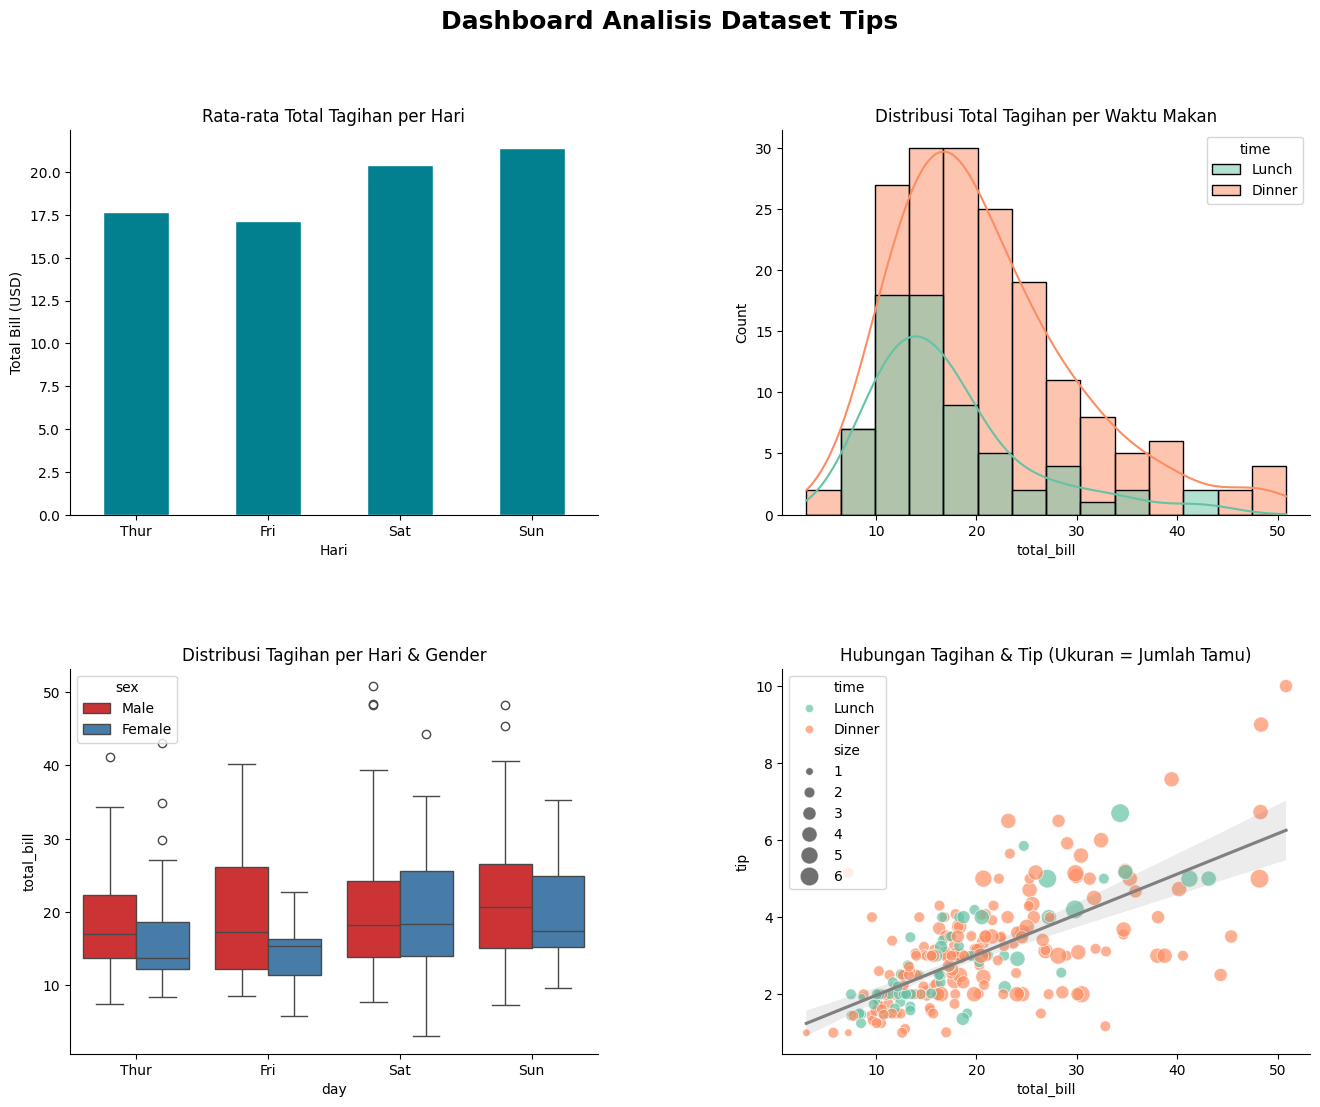

In [3]:
# Layout
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
             fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Bar Chart
avg_by_day = df.groupby('day')['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090',
                edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

# Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', ax=ax2)

ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top', 'right']].set_visible(False)

#  Boxplot
sns.boxplot(data=df, x='day', y='total_bill',
            hue='sex', palette='Set1', ax=ax3)

ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top', 'right']].set_visible(False)

#  Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30,180),
                palette='Set2', alpha=0.7, ax=ax4)

sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray', ax=ax4)

ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top', 'right']].set_visible(False)

In [4]:
# Ekspor
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

<Figure size 640x480 with 0 Axes>

Dashboard tersimpan sebagai dashboard_tips.png


## Grafik 1 – Rata-rata Total Tagihan per Hari (Bar Chart)

**What?**
Grafik menunjukkan rata-rata total tagihan pelanggan pada setiap hari. Minggu memiliki rata-rata tagihan tertinggi, sekitar **USD 21,4**, diikuti Sabtu sekitar **USD 20,4**. Kamis dan Jumat memiliki rata-rata yang lebih rendah, masing-masing sekitar **USD 17,7** dan **USD 17,2**.

**So What?**
Perbedaan ini menunjukkan bahwa pelanggan cenderung mengeluarkan lebih banyak uang pada akhir pekan dibandingkan hari kerja. Hal ini mengindikasikan potensi pendapatan yang lebih besar pada Sabtu dan Minggu sehingga periode tersebut menjadi waktu yang paling penting bagi operasional restoran.

**Now What?**
Restoran dapat meningkatkan jumlah staf dan persediaan pada akhir pekan untuk mengakomodasi transaksi yang lebih besar. Analisis lanjutan dapat dilakukan untuk mengetahui apakah kenaikan tagihan pada akhir pekan dipengaruhi oleh jumlah tamu, durasi kunjungan, atau jenis menu yang dipesan.

---

## Grafik 2 – Distribusi Total Tagihan per Waktu Makan (Histogram + KDE)

**What?**
Distribusi menunjukkan bahwa transaksi **Dinner** memiliki jumlah observasi lebih banyak dan rentang tagihan yang lebih tinggi dibanding **Lunch**. Sebagian besar tagihan Lunch berada pada kisaran **USD 10–20**, sedangkan Dinner tersebar lebih luas hingga mencapai **lebih dari USD 50**.

**So What?**
Hasil ini menunjukkan bahwa makan malam merupakan sumber pendapatan utama restoran. Selain menghasilkan lebih banyak transaksi, pelanggan saat makan malam juga cenderung membelanjakan uang lebih banyak dibandingkan saat makan siang.

**Now What?**
Manajemen dapat memfokuskan promosi atau paket menu premium pada jam makan malam. Selain itu, perlu dilakukan analisis lebih lanjut mengenai menu atau karakteristik pelanggan yang menyebabkan transaksi Dinner memiliki nilai yang lebih tinggi.

---

## Grafik 3 – Distribusi Tagihan per Hari dan Gender (Boxplot)

**What?**
Grafik memperlihatkan distribusi total tagihan berdasarkan hari dan jenis kelamin. Median tagihan pelanggan laki-laki umumnya sedikit lebih tinggi dibanding perempuan pada sebagian besar hari. Selain itu, terdapat beberapa **outlier** dengan tagihan sangat tinggi, terutama pada Sabtu dan Minggu, yang mencapai kisaran **USD 45–50**.

**So What?**
Keberadaan outlier menunjukkan adanya kelompok pelanggan yang mengeluarkan biaya jauh lebih besar daripada pelanggan rata-rata. Variasi tagihan yang lebih besar pada akhir pekan mengindikasikan bahwa perilaku belanja pelanggan menjadi lebih beragam pada hari tersebut.

**Now What?**
Restoran dapat mengidentifikasi karakteristik pelanggan dengan transaksi tinggi untuk menyusun strategi pemasaran yang lebih tepat sasaran. Analisis lanjutan juga dapat dilakukan untuk mengetahui apakah perbedaan tagihan lebih dipengaruhi oleh gender atau oleh faktor lain seperti ukuran kelompok pelanggan.

---

## Grafik 4 – Hubungan Tagihan dan Tip (Scatter Plot + Regresi)

**What?**
Grafik menunjukkan hubungan positif antara **total_bill** dan **tip**. Semakin tinggi nilai tagihan, semakin besar tip yang diberikan pelanggan. Sebagai contoh, transaksi dengan tagihan sekitar **USD 50** menghasilkan tip hingga **USD 9–10**, sedangkan transaksi sekitar **USD 10–15** umumnya menghasilkan tip di bawah **USD 3**.

**So What?**
Hubungan positif ini menunjukkan bahwa peningkatan nilai transaksi berpotensi meningkatkan pendapatan tip bagi staf. Garis regresi yang menanjak mengindikasikan pola yang cukup konsisten antara besarnya tagihan dan tip yang diberikan pelanggan.

**Now What?**
Analisis berikutnya dapat berfokus pada persentase tip terhadap total tagihan untuk mengetahui apakah pelanggan dengan tagihan besar juga lebih dermawan secara proporsional. Hasil ini juga dapat dimanfaatkan untuk merancang strategi *upselling* karena peningkatan nilai transaksi berpotensi memberikan manfaat bagi restoran maupun staf layanan.
